In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cenario = 'NDT'
metodo = 'vwcd_w24_fp2'
threshold = 0.80
ref_metric = 'rtt_down'
if metodo.startswith('vwcd'):
    file = f'{metodo}_{ref_metric}_{threshold}.csv'
else:
    file = f'{metodo}_{ref_metric}.csv'
caminho_csv = os.path.join('segments', cenario, file)

df = pd.read_csv(caminho_csv)

total_clients = df['client'].nunique()
total_servers = df['server'].nunique()
total_client_server_pairs = len(df.groupby(['client', 'server']))

total_blocks = len(df.groupby(['client', 'server', 'block']))
max_blocks_per_pair = df.groupby(['client', 'server'])['block'].nunique().max()

total_segments = len(df)
total_changepoints = total_segments - total_blocks
total_changepoints_per_pair = total_changepoints / total_client_server_pairs if total_client_server_pairs > 0 else 0

min_len = 6
count_below = len(df[df['n_points'] < min_len])

print("=== Segmentation Overview ===")
print(f"Unique Clients:         {total_clients}")
print(f"Unique Servers:         {total_servers}")
print(f"Client-Server Pairs:    {total_client_server_pairs}")
print(f"Total Segments:           {total_blocks}")
print(f"Max Segments in a Pair:   {max_blocks_per_pair}")
print("-----------------------------------")
print(f"Total Changepoints:     {total_changepoints}")
print(f"Changepoints per Pair:  {total_changepoints_per_pair:.2f}")
print(f"Total Intervals:         {total_segments}")
print(f"Number of segments with less than {min_len} points: {count_below}")

=== Segmentation Overview ===
Unique Clients:         16
Unique Servers:         11
Client-Server Pairs:    140
Total Segments:           270
Max Segments in a Pair:   7
-----------------------------------
Total Changepoints:     1039
Changepoints per Pair:  7.42
Total Intervals:         1309
Number of segments with less than 6 points: 8


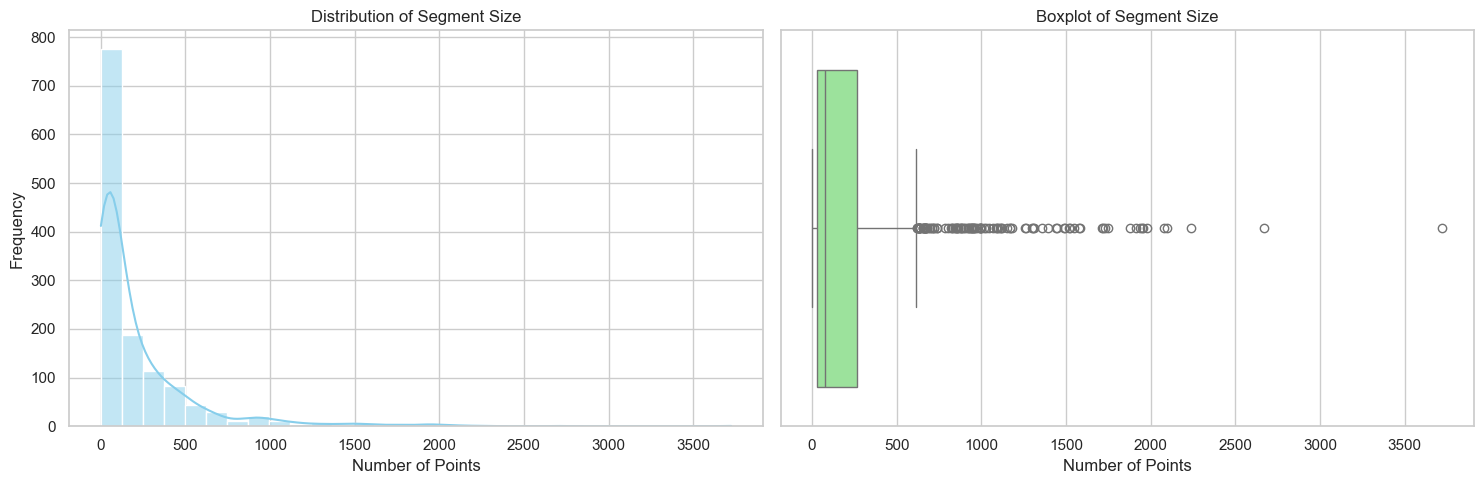

In [15]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=df, x='n_points', bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of Segment Size')
axes[0].set_xlabel('Number of Points')
axes[0].set_ylabel('Frequency')

sns.boxplot(data=df, x='n_points', color='lightgreen', ax=axes[1])
axes[1].set_title('Boxplot of Segment Size')
axes[1].set_xlabel('Number of Points')

plt.tight_layout()
plt.show()